In [11]:
import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

R = 8.314  # J/(mol K)

BASE_DIR = r"C:\Users\user\Desktop\biopigment\data"
TRUSTED = {150: "0226", 300: "0326-2"}      # one reliable series per temperature

PEAK_LO, PEAK_HI = 450, 550
AUC_LO, AUC_HI = 200, 700

PALETTE = {
    "dark":  "#003d5c",
    "teal1": "#005d71",
    "teal2": "#007d67",
    "green": "#1a983f",
    "olive": "#92a800",
    "orange":"#ffa600",
}

In [12]:
def load_spectrum(filepath):
    try:
        df = pd.read_csv(filepath, sep="\t", header=None,
                         names=["w", "a"], comment="#")
        df = df[pd.to_numeric(df["w"], errors="coerce").notna()]
        df = df.astype(float).sort_values("w").reset_index(drop=True)
        return df["w"].to_numpy(), df["a"].to_numpy()
    except Exception:
        return None


def parse_minutes(fn):
    m = re.search(r"(\d+)min", fn)
    return int(m.group(1)) if m else None


def load_trusted_curve(date):
    """One trusted date -> times, peak(t), auc(t)  (averaging any same-time files)."""
    folder = os.path.join(BASE_DIR, date)
    files = glob.glob(os.path.join(folder, "starlab-absorbance-carotene-*.txt"))
    by_time = {}
    for fp in files:
        minutes = parse_minutes(os.path.basename(fp))
        if minutes is None:
            continue
        spec = load_spectrum(fp)
        if spec is None:
            continue
        wl, ab = spec
        pmask = (wl >= PEAK_LO) & (wl <= PEAK_HI)
        amask = (wl >= AUC_LO) & (wl <= AUC_HI)
        pk = ab[pmask].mean()
        au = np.trapezoid(ab[amask], wl[amask])
        by_time.setdefault(minutes, []).append((pk, au))
    times = np.array(sorted(by_time))
    peak = np.array([np.mean([v[0] for v in by_time[t]]) for t in times])
    auc = np.array([np.mean([v[1] for v in by_time[t]]) for t in times])
    return times, peak, auc


In [13]:
def first_order(t, A0, k):
    return A0 * np.exp(-k * t)


def fit_k(times, values):
    norm = values / values[0]
    popt, pcov = curve_fit(first_order, times, norm, p0=[1.0, 0.01], maxfev=10000)
    k = popt[1]
    k_se = np.sqrt(np.diag(pcov))[1]
    resid = norm - first_order(times, *popt)
    ss_res = np.sum(resid**2); ss_tot = np.sum((norm - norm.mean())**2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
    return k, k_se, r2

In [14]:
def build_data():
    data = {"peak": {"T": [], "k": [], "ke": [], "r2": [], "color":PALETTE["orange"]},
            "auc":  {"T": [], "k": [], "ke": [], "r2": [], "color":PALETTE["teal2"]}}
    for temp in sorted(TRUSTED):
        times, peak, auc = load_trusted_curve(TRUSTED[temp])
        for name, vals in [("peak", peak), ("auc", auc)]:
            k, ke, r2 = fit_k(times, vals)
            data[name]["T"].append(temp)
            data[name]["k"].append(k)
            data[name]["ke"].append(ke)
            data[name]["r2"].append(r2)
    return data


=== rate constants computed from trusted series (min^-1) ===
  peak 150C (0226): k=0.01133, SE=0.00073, R2=0.982
  peak 300C (0326-2): k=0.04200, SE=0.00654, R2=0.936
  auc 150C (0226): k=0.00462, SE=0.00040, R2=0.956
  auc 300C (0326-2): k=0.01295, SE=0.00109, R2=0.969


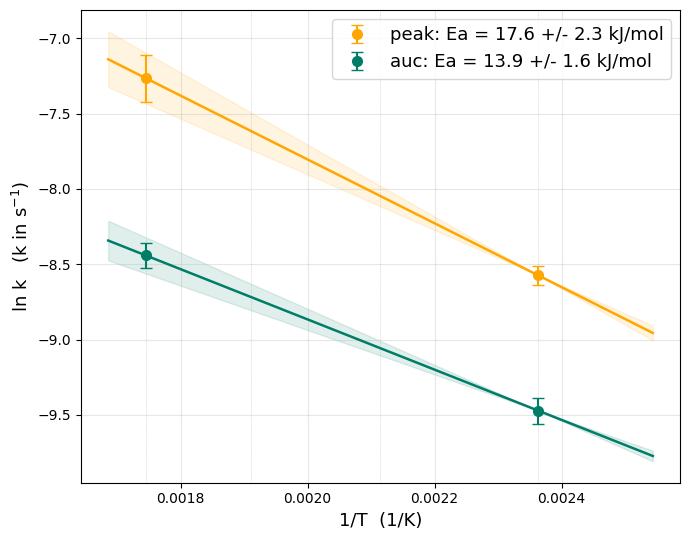


=== Arrhenius summary ===
  peak: Ea = 17.61 +/- 2.27 kJ/mol, A = 2.818e-02 s^-1
  auc: Ea = 13.86 +/- 1.61 kJ/mol, A = 3.958e-03 s^-1


In [15]:
def kelvin(c):
    return np.array(c, dtype=float) + 273.15


def arrhenius_params(T, k):
    x = 1.0 / T
    y = np.log(k)
    slope = (y[1] - y[0]) / (x[1] - x[0])
    intercept = y[0] - slope * x[0]
    return -slope * R, intercept           # Ea, lnA


def Ea_sigma(T, k, ke):
    denom = 1.0 / T[0] - 1.0 / T[1]
    rel = np.sqrt((ke[1] / k[1])**2 + (ke[0] / k[0])**2)
    return abs(R / denom) * rel


def main():
    DATA = build_data()

    # report the auto-computed k and SE
    print("=== rate constants computed from trusted series (min^-1) ===")
    for name in ("peak", "auc"):
        d = DATA[name]
        for i, temp in enumerate(d["T"]):
            print(f"  {name} {temp}C ({TRUSTED[temp]}): "
                  f"k={d['k'][i]:.5f}, SE={d['ke'][i]:.5f}, R2={d['r2'][i]:.3f}")

    fig, ax = plt.subplots(figsize=(7, 5.5))
    xfit = np.linspace(1.0 / kelvin(320), 1.0 / kelvin(120), 100)

    summary = {}
    for name in ("peak", "auc"):
        d = DATA[name]
        T = kelvin(d["T"])
        k = np.array(d["k"]) / 60.0          # min^-1 -> s^-1
        ke = np.array(d["ke"]) / 60.0
        color = d["color"]

        Ea, lnA = arrhenius_params(T, k)
        sEa = Ea_sigma(T, k, ke)
        summary[name] = (Ea, sEa, np.exp(lnA))

        x = 1.0 / T
        y = np.log(k)
        ax.errorbar(x, y, yerr=ke / k, fmt="o", color=color, ms=7, capsize=4,
                    label=f"{name}: Ea = {Ea/1000:.1f} +/- {sEa/1000:.1f} kJ/mol",
                    zorder=5)
        slope = -Ea / R
        ax.plot(xfit, lnA + slope * xfit, color=color, lw=1.8)

        s_lo, s_hi = -(Ea + sEa) / R, -(Ea - sEa) / R
        lnA_lo = y[0] - s_lo * x[0]
        lnA_hi = y[0] - s_hi * x[0]
        ax.fill_between(xfit, lnA_lo + s_lo * xfit, lnA_hi + s_hi * xfit,
                        color=color, alpha=0.12)

    for Tc in [150, 200, 250, 300]:
        ax.axvline(1.0 / kelvin(Tc), color="grey", ls=":", lw=0.5, alpha=0.5)

    ax.set_xlabel("1/T  (1/K)", fontsize=13)
    ax.set_ylabel("ln k   (k in s$^{-1}$)", fontsize=13)
    ax.legend(fontsize=13, loc="upper right")
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    plt.savefig("arrhenius.png", dpi=300, bbox_inches="tight")
    plt.show()

    print("\n=== Arrhenius summary ===")
    for name, (Ea, sEa, A) in summary.items():
        print(f"  {name}: Ea = {Ea/1000:.2f} +/- {sEa/1000:.2f} kJ/mol, A = {A:.3e} s^-1")


if __name__ == "__main__":
    main()
